<a href="https://colab.research.google.com/github/IdoiaUrra-TFG/TFG---SVMs-con-Kernels-Ortogonales-Un-Estudio-de-Sensibilidad-por-Grado/blob/main/Ejemplo_transformaci%C3%B3n_del_kernel_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Datos que no pueden separarse mediante una línea recta en un espacio de dos dimensiones, se vuelven linealmente separables al proyectarlos en un espacio tridimensional mediante una transformación.

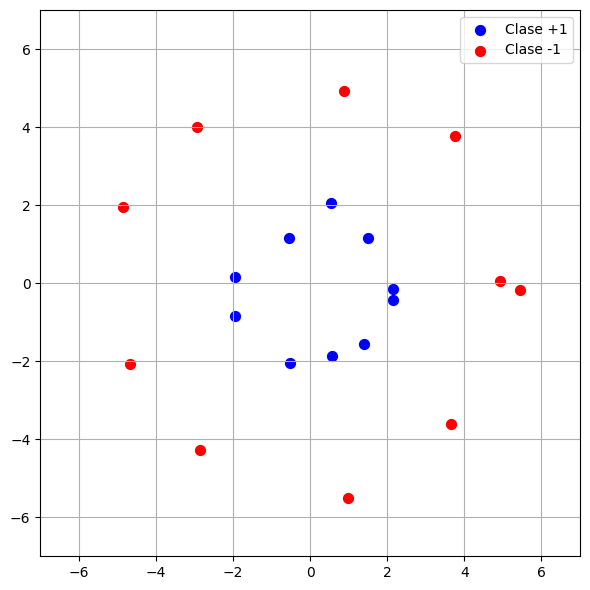

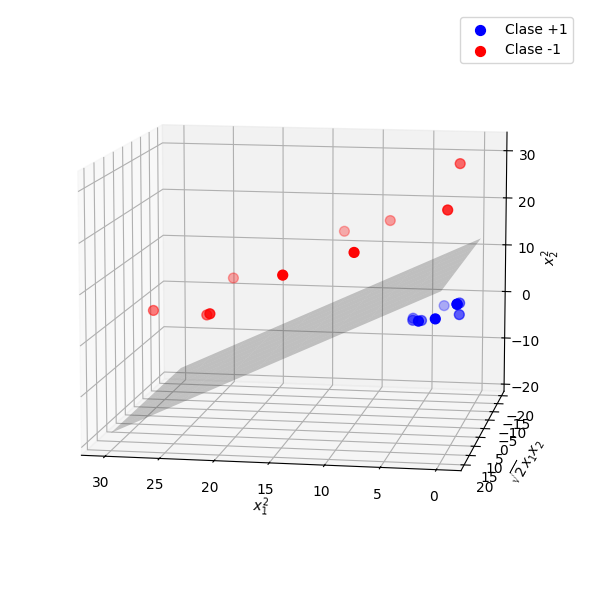

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# Azules: dentro de un círculo de radio 3 (mezclados con rojos en 2D)
angulos1 = np.linspace(0, 2*np.pi, 10)
clase1 = np.column_stack([
    2*np.cos(angulos1) + np.random.normal(0, 0.3, 10),
    2*np.sin(angulos1) + np.random.normal(0, 0.3, 10)
])

# Rojos: fuera del círculo de radio 3
angulos2 = np.linspace(0, 2*np.pi, 10)
clase2 = np.column_stack([
    5*np.cos(angulos2) + np.random.normal(0, 0.3, 10),
    5*np.sin(angulos2) + np.random.normal(0, 0.3, 10)
])

# FIGURA 1: datos en 2D (mezclados, no separables linealmente)
fig1, ax = plt.subplots(figsize=(6,6))
ax.scatter(clase1[:,0], clase1[:,1], c='blue', marker='o', s=50, label='Clase +1')
ax.scatter(clase2[:,0], clase2[:,1], c='red', marker='o', s=50, label='Clase -1')
ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig('figura_2D.png', dpi=150, bbox_inches='tight')
plt.show()

# Transformación phi
def phi(X):
    x1, x2 = X[:,0], X[:,1]
    return np.column_stack([x1**2, np.sqrt(2)*x1*x2, x2**2])

clase1_3d = phi(clase1)
clase2_3d = phi(clase2)

# FIGURA 2: datos en 3D separables
fig2 = plt.figure(figsize=(8,6))
ax3d = fig2.add_subplot(111, projection='3d')
ax3d.scatter(clase1_3d[:,0], clase1_3d[:,1], clase1_3d[:,2],
             c='blue', marker='o', s=50, label='Clase +1')
ax3d.scatter(clase2_3d[:,0], clase2_3d[:,1], clase2_3d[:,2],
             c='red', marker='o', s=50, label='Clase -1')

# Plano separador
xx, yy = np.meshgrid(np.linspace(0, 30, 10), np.linspace(-20, 20, 10))
zz = 12 - xx
ax3d.plot_surface(xx, yy, zz, alpha=0.3, color='gray')

ax3d.set_xlabel('$x_1^2$')
ax3d.set_ylabel('$\\sqrt{2}x_1x_2$')
ax3d.set_zlabel('$x_2^2$')
ax3d.view_init(elev=10, azim=100)
ax3d.legend()

plt.tight_layout()
plt.savefig('figura_3D.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('figura_2D.png')
files.download('figura_3D.png')